### Imports

In [ ]:
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

### Constants and Seed Setting

In [ ]:
#TODO: Add constants from code below

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


### Loading Datasets 

In [ ]:
TRAIN_PT_PATH = "/content/train_sampled_esm2_650m.pt"
VAL_PT_PATH   = "/content/val_full_esm2_650m.pt"

TRAIN_CSV_PATH = "/content/tsuboyama_processed_train_sampled.csv"
VAL_CSV_PATH   = "/content/tsuboyama_processed_val_full (1).csv"

for path in [TRAIN_PT_PATH, VAL_PT_PATH, TRAIN_CSV_PATH, VAL_CSV_PATH]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find: {path}")


train_data = torch.load(TRAIN_PT_PATH, map_location="cpu")
val_data   = torch.load(VAL_PT_PATH, map_location="cpu")

train_df = pd.read_csv(TRAIN_CSV_PATH)
val_df   = pd.read_csv(VAL_CSV_PATH)


### Embeddings and targets

In [ ]:
def extract_X_y(data, name="dataset"):
    if not isinstance(data, dict):
        raise TypeError(f"{name} must be a dict. Found: {type(data)}")

    X = data["seq_embeddings"]
    y = data["delta_g"]

    if not torch.is_tensor(X):
        X = torch.tensor(X)
    if not torch.is_tensor(y):
        y = torch.tensor(y)

    X = X.float()
    y = y.float().view(-1)

    print(f"{name}: X shape = {tuple(X.shape)}, y shape = {tuple(y.shape)}")
    return X, y

X_train, y_train = extract_X_y(train_data, name="train_data")
X_val, y_val     = extract_X_y(val_data, name="val_data")

if X_train.ndim != 2 or X_val.ndim != 2:
    raise ValueError("Expected embeddings to be 2D.")
if X_train.shape[1] != X_val.shape[1]:
    raise ValueError("Train and validation embedding dimensions do not match.")
if len(X_train) != len(y_train):
    raise ValueError("Train X and y lengths do not match.")
if len(X_val) != len(y_val):
    raise ValueError("Validation X and y lengths do not match.")

input_dim = X_train.shape[1]
print("Input embedding dimension:", input_dim)


### Tabular cleanup

In [ ]:
# ----------------------------
# 5) Minimal tabular cleanup
# ----------------------------
# Accept either delta_g or deltaG depending on file version

TARGET_COL = None

if "delta_g" in train_df.columns:
    TARGET_COL = "delta_g"
elif "deltaG" in train_df.columns:
    TARGET_COL = "deltaG"
else:
    raise ValueError("Could not find delta_g or deltaG column in train_df")

print("Using target column:", TARGET_COL)

REQUIRED_COLS = [TARGET_COL, "aa_seq", "WT_cluster"]

for name, df in [("train_df", train_df), ("val_df", val_df)]:
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{name} is missing required columns: {missing}")
for name, df in [("train_df", train_df), ("val_df", val_df)]:
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{name} is missing required columns: {missing}")

def basic_clean(df):
    df = df.copy()
    df = df.dropna(subset=[TARGET_COL, "aa_seq", "WT_cluster"])
    df["aa_seq"] = df["aa_seq"].astype(str)
    df["WT_cluster"] = df["WT_cluster"].astype(str)
    if "mut_type" in df.columns:
        df["mut_type"] = df["mut_type"].astype(str)
    df["seq_len"] = df["aa_seq"].str.len()
    return df

train_df = basic_clean(train_df)
val_df   = basic_clean(val_df)

print("Cleaned train_df shape:", train_df.shape)
print("Cleaned val_df shape:  ", val_df.shape)

# ----------------------------
# 5b) Minimal tabular cleanup
# ----------------------------
TARGET_COL = None

if "delta_g" in train_df.columns:
    TARGET_COL = "delta_g"
elif "deltaG" in train_df.columns:
    TARGET_COL = "deltaG"
else:
    raise ValueError("Could not find delta_g or deltaG column in train_df")

print("Using target column:", TARGET_COL)

REQUIRED_COLS = [TARGET_COL, "aa_seq", "WT_cluster"]

for name, df in [("train_df", train_df), ("val_df", val_df)]:
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{name} is missing required columns: {missing}")

def basic_clean(df):
    df = df.copy()
    df = df.dropna(subset=[TARGET_COL, "aa_seq", "WT_cluster"])
    df["aa_seq"] = df["aa_seq"].astype(str)
    df["WT_cluster"] = df["WT_cluster"].astype(str)
    if "mut_type" in df.columns:
        df["mut_type"] = df["mut_type"].astype(str)
    df["seq_len"] = df["aa_seq"].str.len()
    return df

train_df = basic_clean(train_df)
val_df   = basic_clean(val_df)

print("Cleaned train_df shape:", train_df.shape)
print("Cleaned val_df shape:  ", val_df.shape)


### Exploratory Data Analysis

In [ ]:
# ----------------------------
# 6) Light EDA
# ----------------------------
def plot_hist(series, bins, xlabel, title):
    plt.figure(figsize=(6, 4))
    plt.hist(series.dropna().values, bins=bins)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    plt.show()

print("\n=== Target summary ===")
print(f"Train {TARGET_COL}:\n", train_df[TARGET_COL].describe())
print(f"\nVal {TARGET_COL}:\n", val_df[TARGET_COL].describe())

print("\n=== Sequence length summary ===")
print("Train seq_len:\n", train_df["seq_len"].describe())
print("\nVal seq_len:\n", val_df["seq_len"].describe())

plot_hist(train_df[TARGET_COL], bins=60, xlabel=TARGET_COL, title=f"Train {TARGET_COL} distribution")
plot_hist(val_df[TARGET_COL], bins=60, xlabel=TARGET_COL, title=f"Validation {TARGET_COL} distribution")

plot_hist(train_df["seq_len"], bins=40, xlabel="Sequence length", title="Train sequence length distribution")
plot_hist(val_df["seq_len"], bins=40, xlabel="Sequence length", title="Validation sequence length distribution")

train_embed_norm = torch.norm(X_train, dim=1).cpu().numpy()
val_embed_norm   = torch.norm(X_val, dim=1).cpu().numpy()

print("\n=== Embedding norm summary ===")
print("Train embedding norms:\n", pd.Series(train_embed_norm).describe())
print("\nVal embedding norms:\n", pd.Series(val_embed_norm).describe())

plot_hist(pd.Series(train_embed_norm), bins=50, xlabel="Embedding L2 norm", title="Train embedding norm distribution")
plot_hist(pd.Series(val_embed_norm), bins=50, xlabel="Embedding L2 norm", title="Validation embedding norm distribution")

# Optional quick PCA visualization
n_pca = min(3000, len(X_train), len(X_val))
rng = np.random.RandomState(42)
train_idx = rng.choice(len(X_train), size=n_pca, replace=False)
val_idx   = rng.choice(len(X_val), size=n_pca, replace=False)

X_vis = np.concatenate([
    X_train[train_idx].cpu().numpy(),
    X_val[val_idx].cpu().numpy()
], axis=0)

labels = np.array(["train"] * n_pca + ["val"] * n_pca)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_vis)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[labels == "train", 0], X_pca[labels == "train", 1], alpha=0.2, label="train")
plt.scatter(X_pca[labels == "val", 0], X_pca[labels == "val", 1], alpha=0.2, label="val")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of ESM-2 embeddings")
plt.legend()
plt.tight_layout()
plt.show()

print("PCA explained variance ratio:", np.round(pca.explained_variance_ratio_, 4))

### Spearman Helper

In [ ]:
# ----------------------------
# 7) Spearman helper
# ----------------------------
def spearmanr_np(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    def rankdata(a):
        order = a.argsort()
        ranks = np.empty_like(order, dtype=float)
        ranks[order] = np.arange(len(a), dtype=float)
        _, inv, counts = np.unique(a, return_inverse=True, return_counts=True)
        sums = np.bincount(inv, ranks)
        avg = sums / counts
        return avg[inv]

    rx = rankdata(x)
    ry = rankdata(y)
    rx -= rx.mean()
    ry -= ry.mean()
    denom = np.sqrt((rx ** 2).sum() * (ry ** 2).sum())
    return float((rx * ry).sum() / denom) if denom != 0 else np.nan


### Dataset and Dataloader

In [ ]:
# ----------------------------
# 8) Dataset + DataLoader
# ----------------------------
class EmbeddingDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.float()
        self.y = y.float()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 512 if torch.cuda.is_available() else 256

train_ds = EmbeddingDataset(X_train, y_train)
val_ds   = EmbeddingDataset(X_val, y_val)

### Model

In [ ]:
# ============================================================
# Tsuboyama Baseline: MLP on ESM-2 embeddings (clean version)
# - Loads 60k train + full validation ESM embedding files
# - Runs light EDA
# - Trains an MLP regressor for delta_g
# - Evaluates MAE / RMSE / R2 / Spearman
# - Runs multiple seeds and reports mean ± SD and variance
# ============================================================
# ----------------------------
# 9) Model
# ----------------------------
class MLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

### Training and Evaluation Helpers

In [ ]:
# ----------------------------
# 10) Train / eval helpers
# ----------------------------
def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)

    losses = []
    y_true = []
    y_pred = []

    with torch.set_grad_enabled(train_mode):
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            if train_mode:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            losses.append(loss.item())
            y_true.append(y_batch.detach().cpu().numpy())
            y_pred.append(preds.detach().cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    return {
        "loss": float(np.mean(losses)),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(math.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
        "spearman": float(spearmanr_np(y_true, y_pred))
    }

def train_one_seed(seed, epochs=10, lr=2e-3, weight_decay=1e-4):
    print("\n" + "=" * 70)
    print(f"Training seed {seed}")
    print("=" * 70)

    set_seed(seed)

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    model = MLPRegressor(input_dim=input_dim).to(device)
    criterion = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )

    best_val_mae = float("inf")
    best_metrics = None
    best_state = None

    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_metrics   = run_epoch(model, val_loader, criterion, optimizer=None)

        scheduler.step(val_metrics["loss"])

        print(
            f"Epoch {epoch:02d} | "
            f"train loss {train_metrics['loss']:.4f} "
            f"MAE {train_metrics['mae']:.4f} "
            f"RMSE {train_metrics['rmse']:.4f} "
            f"R2 {train_metrics['r2']:.4f} "
            f"Spearman {train_metrics['spearman']:.4f} | "
            f"val loss {val_metrics['loss']:.4f} "
            f"MAE {val_metrics['mae']:.4f} "
            f"RMSE {val_metrics['rmse']:.4f} "
            f"R2 {val_metrics['r2']:.4f} "
            f"Spearman {val_metrics['spearman']:.4f}"
        )

        if val_metrics["mae"] < best_val_mae:
            best_val_mae = val_metrics["mae"]
            best_metrics = val_metrics.copy()
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)

    save_path = f"/content/mlp_esm2_seed{seed}.pt"
    torch.save(
        {
            "state_dict": model.state_dict(),
            "input_dim": input_dim,
            "seed": seed,
            "best_val_metrics": best_metrics
        },
        save_path
    )

    print(f"Best validation MAE for seed {seed}: {best_val_mae:.4f}")
    return best_metrics


### Running the model

Device: cpu
train_data: X shape = (60000, 1280), y shape = (60000,)
val_data: X shape = (56731, 1280), y shape = (56731,)
Input embedding dimension: 1280
Using target column: deltaG
Cleaned train_df shape: (60000, 8)
Cleaned val_df shape:   (56731, 8)
Using target column: deltaG
Cleaned train_df shape: (60000, 8)
Cleaned val_df shape:   (56731, 8)

=== Target summary ===
Train deltaG:
 count    60000.000000
mean         2.389875
std          2.081708
min         -8.633250
25%          1.190140
50%          2.338591
75%          3.546114
max         14.956007
Name: deltaG, dtype: float64

Val deltaG:
 count    56731.000000
mean         2.398184
std          1.950596
min         -7.565291
25%          1.291735
50%          2.421936
75%          3.518932
max         14.964533
Name: deltaG, dtype: float64

=== Sequence length summary ===
Train seq_len:
 count    60000.000000
mean        56.141433
std         10.368260
min         32.000000
25%         47.000000
50%         57.000000
75%   

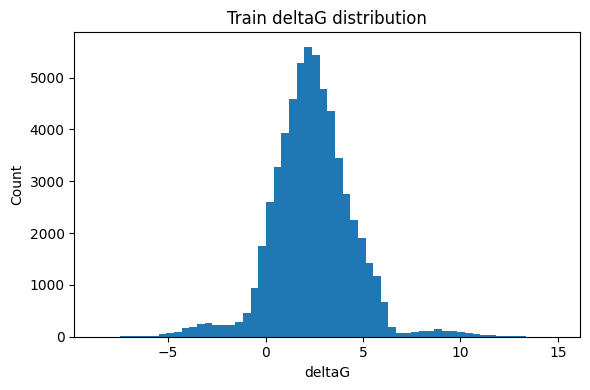

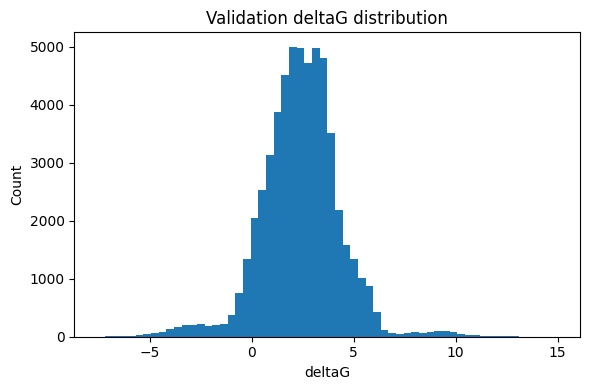

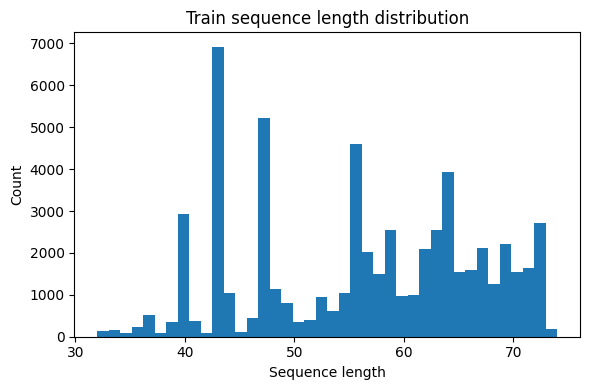

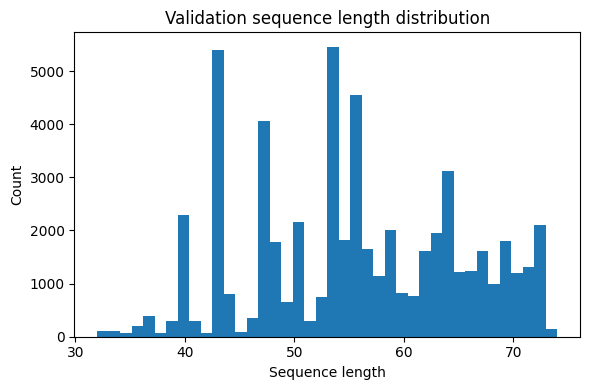


=== Embedding norm summary ===
Train embedding norms:
 count    60000.000000
mean         7.829610
std          1.188389
min          5.123371
25%          6.839654
50%          8.007252
75%          8.898574
max          9.880250
dtype: float64

Val embedding norms:
 count    56731.000000
mean         8.096163
std          1.236542
min          5.140579
25%          7.071498
50%          8.495625
75%          9.187553
max          9.833194
dtype: float64


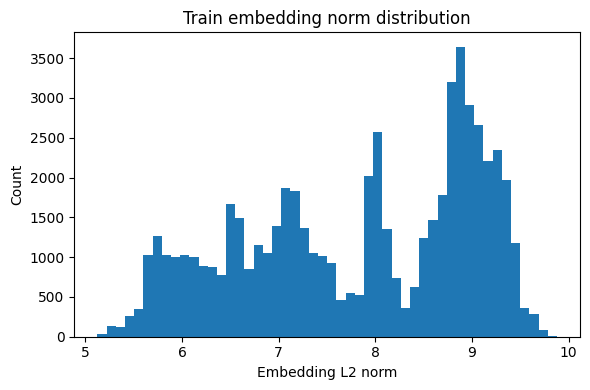

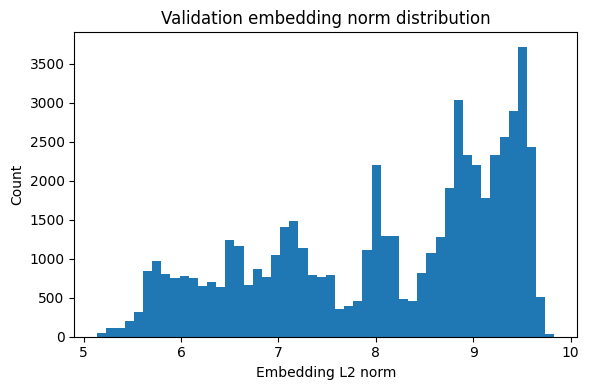

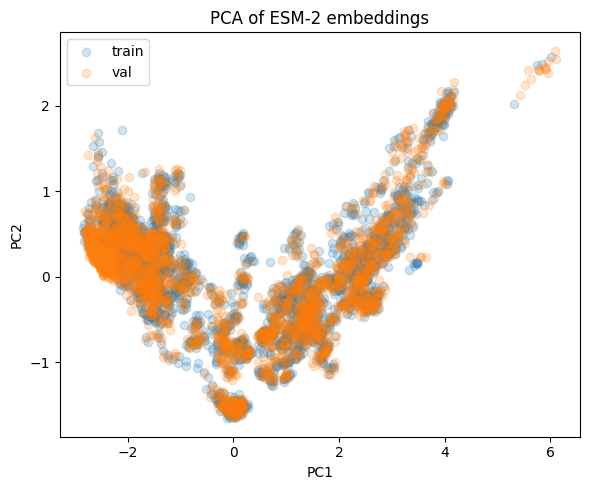

PCA explained variance ratio: [0.4981 0.0642]

Training seed 1
Epoch 01 | train loss 3.0245 MAE 1.2371 RMSE 1.7401 R2 0.3012 Spearman 0.5597 | val loss 2.3754 MAE 1.1221 RMSE 1.5425 R2 0.3746 Spearman 0.6081
Epoch 02 | train loss 2.0990 MAE 1.0092 RMSE 1.4491 R2 0.5154 Spearman 0.7276 | val loss 2.4891 MAE 1.1803 RMSE 1.5789 R2 0.3448 Spearman 0.6327
Epoch 03 | train loss 1.8518 MAE 0.9433 RMSE 1.3608 R2 0.5727 Spearman 0.7618 | val loss 2.2015 MAE 1.0750 RMSE 1.4848 R2 0.4206 Spearman 0.6648
Epoch 04 | train loss 1.7402 MAE 0.9080 RMSE 1.3199 R2 0.5980 Spearman 0.7794 | val loss 2.1698 MAE 1.0379 RMSE 1.4742 R2 0.4288 Spearman 0.6469
Epoch 05 | train loss 1.6850 MAE 0.8934 RMSE 1.2979 R2 0.6113 Spearman 0.7860 | val loss 1.9932 MAE 1.0022 RMSE 1.4128 R2 0.4754 Spearman 0.6755
Epoch 06 | train loss 1.6027 MAE 0.8663 RMSE 1.2656 R2 0.6304 Spearman 0.7988 | val loss 2.1146 MAE 1.0540 RMSE 1.4554 R2 0.4433 Spearman 0.6995
Epoch 07 | train loss 1.5412 MAE 0.8480 RMSE 1.2406 R2 0.6448 Spear

In [ ]:
### Previous outputs
# ----------------------------
# 11) Run multiple seeds
# ----------------------------
SEEDS = [1, 2, 3, 4, 5]
EPOCHS = 10

all_results = []
for seed in SEEDS:
    metrics = train_one_seed(seed=seed, epochs=EPOCHS)
    metrics["seed"] = seed
    all_results.append(metrics)

# ----------------------------
# 12) Final summary
# ----------------------------
def summarize(values):
    values = np.array(values, dtype=float)
    return values.mean(), values.std(ddof=1), values.var(ddof=1)

maes  = [r["mae"] for r in all_results]
rmses = [r["rmse"] for r in all_results]
r2s   = [r["r2"] for r in all_results]
sps   = [r["spearman"] for r in all_results]

mae_mean, mae_std, mae_var = summarize(maes)
rmse_mean, rmse_std, rmse_var = summarize(rmses)
r2_mean, r2_std, r2_var = summarize(r2s)
sp_mean, sp_std, sp_var = summarize(sps)

print("\n" + "=" * 70)
print("Final validation results across seeds")
print("=" * 70)

for r in all_results:
    print(
        f"Seed {r['seed']} | "
        f"MAE {r['mae']:.4f} | "
        f"RMSE {r['rmse']:.4f} | "
        f"R2 {r['r2']:.4f} | "
        f"Spearman {r['spearman']:.4f}"
    )

print("\nMean ± SD across seeds:")
print(f"MAE      = {mae_mean:.4f} ± {mae_std:.4f}")
print(f"RMSE     = {rmse_mean:.4f} ± {rmse_std:.4f}")
print(f"R2       = {r2_mean:.4f} ± {r2_std:.4f}")
print(f"Spearman = {sp_mean:.4f} ± {sp_std:.4f}")

print("\nVariance across seeds:")
print(f"MAE variance      = {mae_var:.6f}")
print(f"RMSE variance     = {rmse_var:.6f}")
print(f"R2 variance       = {r2_var:.6f}")
print(f"Spearman variance = {sp_var:.6f}")